### **6.1. CNN Simple desde Cero**

Cargando MNIST...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenamiento: (60000, 28, 28, 1)
Test: (10000, 28, 28, 1)

Entrenando...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 96ms/step - accuracy: 0.9152 - loss: 0.2752 - val_accuracy: 0.9810 - val_loss: 0.0641
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - accuracy: 0.9730 - loss: 0.0848 - val_accuracy: 0.9880 - val_loss: 0.0441
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9817 - loss: 0.0589 - val_accuracy: 0.9897 - val_loss: 0.0397
Precision en test: 98.77%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


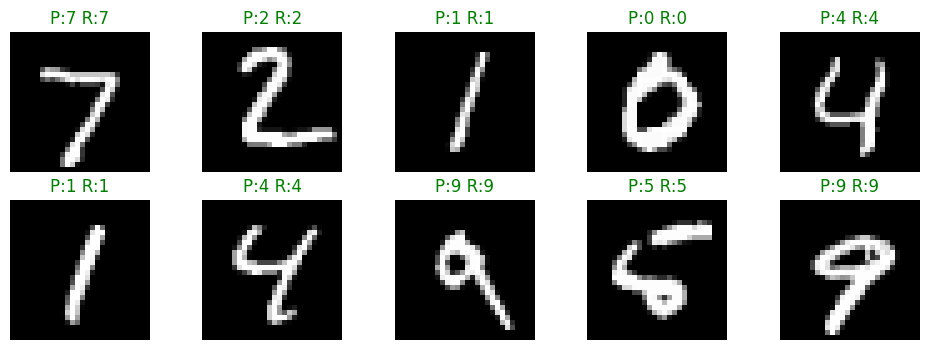

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("Cargando MNIST...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"Entrenamiento: {x_train.shape}")
print(f"Test: {x_test.shape}")

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\nEntrenando...")
model.fit(x_train, y_train, epochs=3, batch_size=128, validation_split=0.1)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Precision en test: {test_acc*100:.2f}%")

preds = model.predict(x_test[:10])
fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
    pred = np.argmax(preds[i])
    real = y_test[i]
    ax.set_title(f"P:{pred} R:{real}", color='green' if pred==real else 'red')
    ax.axis('off')
plt.show()

### **6.2. Detección de Bordes - Convoluciones Manuales**

Descargando imagen...


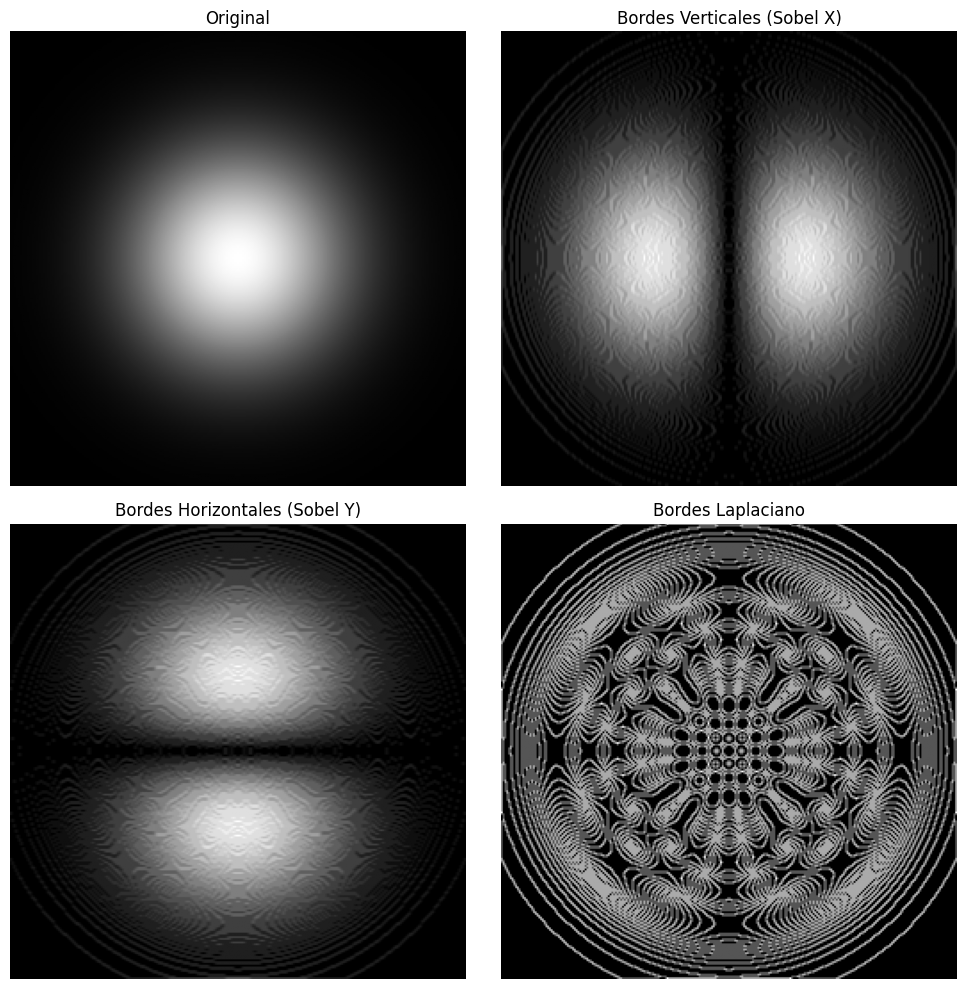

CNN aprende filtros como estos automaticamente!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from PIL import Image
import urllib.request

print("Descargando imagen...")
try:
    url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/256px-Cat03.jpg'
    urllib.request.urlretrieve(url, 'sample.jpg')
    img = Image.open('sample.jpg').convert('L').resize((256, 256))
except:
    x = np.linspace(-3, 3, 256)
    y = np.linspace(-3, 3, 256)
    X, Y = np.meshgrid(x, y)
    img = Image.fromarray((np.exp(-(X**2 + Y**2)/2) * 255).astype(np.uint8))

img_array = np.array(img, dtype=np.float32) / 255.0

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
laplacian = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=np.float32)

bordes_x = np.abs(signal.correlate2d(img_array, sobel_x, mode='same'))
bordes_y = np.abs(signal.correlate2d(img_array, sobel_y, mode='same'))
bordes_lap = np.abs(signal.correlate2d(img_array, laplacian, mode='same'))

bordes_x = bordes_x / np.max(bordes_x)
bordes_y = bordes_y / np.max(bordes_y)
bordes_lap = bordes_lap / np.max(bordes_lap)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].imshow(img_array, cmap='gray')
axes[0,0].set_title('Original')
axes[0,1].imshow(bordes_x, cmap='gray')
axes[0,1].set_title('Bordes Verticales (Sobel X)')
axes[1,0].imshow(bordes_y, cmap='gray')
axes[1,0].set_title('Bordes Horizontales (Sobel Y)')
axes[1,1].imshow(bordes_lap, cmap='gray')
axes[1,1].set_title('Bordes Laplaciano')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

print("CNN aprende filtros como estos automaticamente!")

### **6.3. Clasificación CIFAR-10 - Objetos Reales en Color**

Cargando CIFAR-10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Entrenamiento: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)

Entrenando...
Epoch 1/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 75s 416ms/step - accuracy: 0.3687 - loss: 1.7386 - val_accuracy: 0.4942 - val_loss: 1.4079
Epoch 2/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 76s 384ms/step - accuracy: 0.5034 - loss: 1.3818 - val_accuracy: 0.5632 - val_loss: 1.2283
Epoch 3/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 67s 381ms/step - accuracy: 0.5592 - loss: 1.2346 - val_accuracy: 0.6182 - val_loss: 1.0978
Precision: 60.57%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


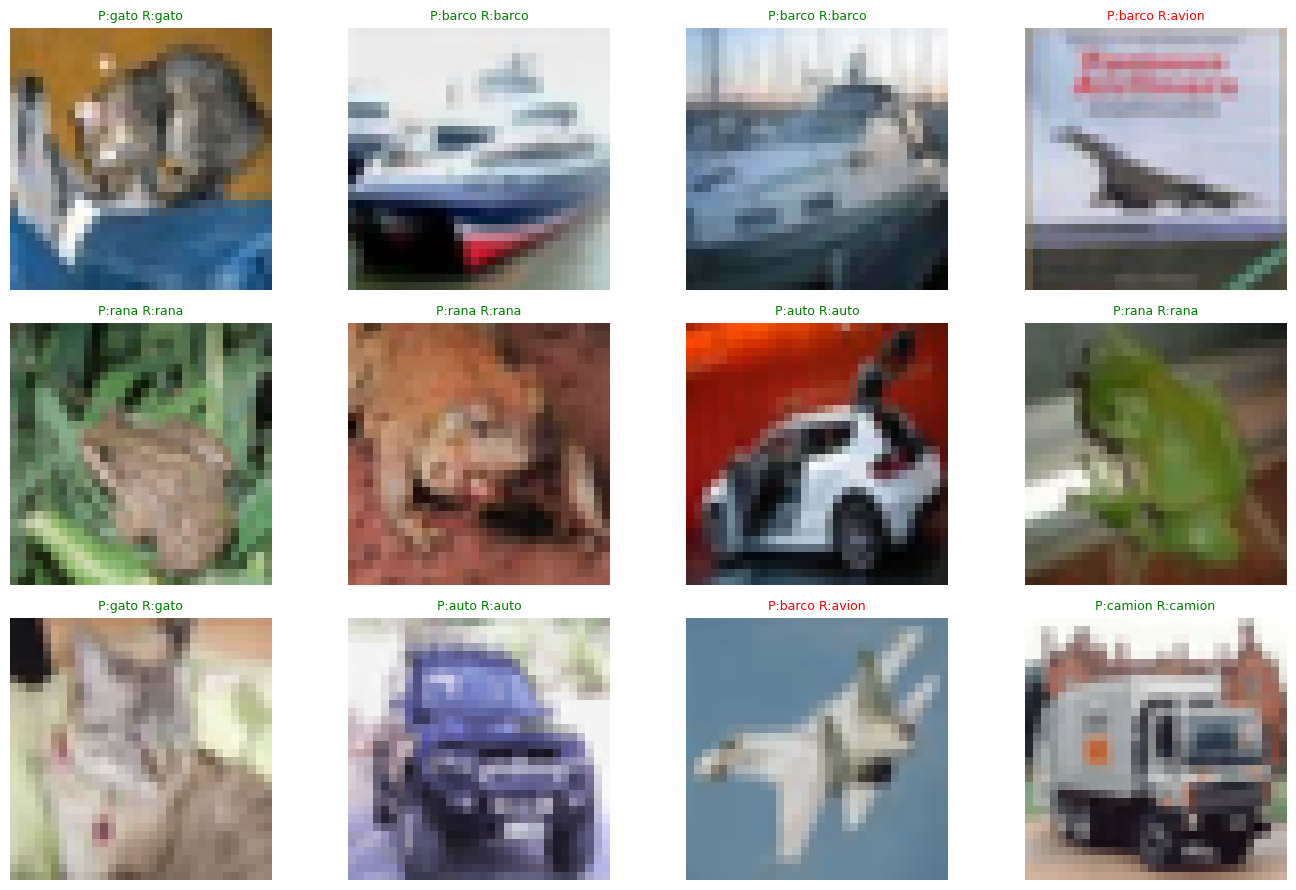

Clasificacion completada!


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

clases = ['avion', 'auto', 'pajaro', 'gato', 'ciervo',
          'perro', 'rana', 'caballo', 'barco', 'camion']

print("Cargando CIFAR-10...")
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()

print(f"Entrenamiento: {x_train.shape}")
print(f"Test: {x_test.shape}")

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\nEntrenando...")
model.fit(x_train, y_train, epochs=3, batch_size=256, validation_split=0.1, verbose=1)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Precision: {test_acc*100:.2f}%")

preds = model.predict(x_test[:12])
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i])
    pred = np.argmax(preds[i])
    real = y_test[i]
    ax.set_title(f"P:{clases[pred]} R:{clases[real]}",
                 color='green' if pred==real else 'red', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

print("Clasificacion completada!")

### **6.4. Análisis de Confianza y Errores**

Generando predicciones en test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step
Confianza promedio: 54.68%


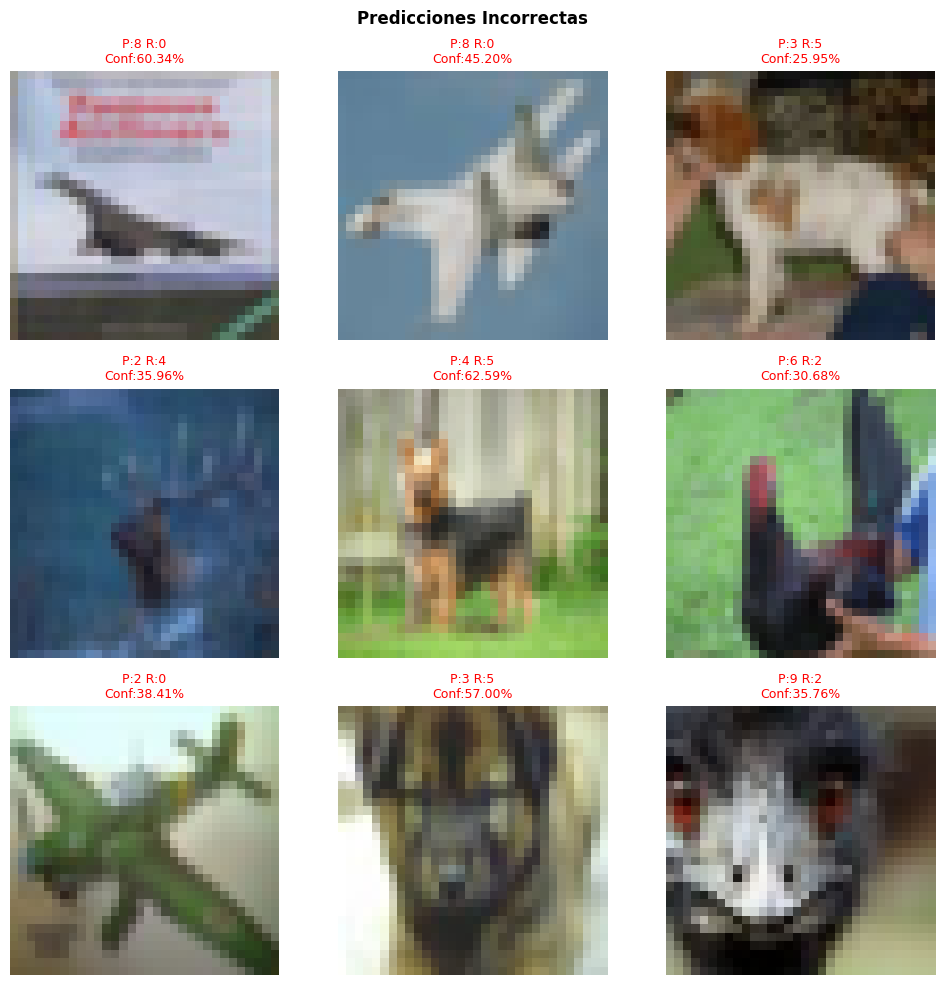

Errores totales: 3943/10000
Tasa de acierto: 60.57%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("Generando predicciones en test set...")
predicciones = model.predict(x_test)
predichas = np.argmax(predicciones, axis=1)

confianza_max = np.max(predicciones, axis=1)
confianza_promedio = np.mean(confianza_max)
print(f"Confianza promedio: {confianza_promedio*100:.2f}%")

correctas = (predichas == y_test)
incorrectas = ~correctas

indices_error = np.where(incorrectas)[0][:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for idx, ax_idx in enumerate(indices_error):
    ax = axes.flat[idx]
    ax.imshow(x_test[ax_idx])
    pred = predichas[ax_idx]
    real = y_test[ax_idx]
    conf = confianza_max[ax_idx]
    ax.set_title(f"P:{pred} R:{real}\nConf:{conf:.2%}", fontsize=9, color='red')
    ax.axis('off')

plt.suptitle('Predicciones Incorrectas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, predichas)
print(f"Errores totales: {np.sum(incorrectas)}/10000")
print(f"Tasa de acierto: {np.sum(correctas)/len(y_test)*100:.2f}%")